# EEG GNN — Parameter Sweep & Evaluation

**File layout expected (all in same directory):**
```
preprocessing.py   ← your existing file (PreprocessingPipeline, ExperimentConfig, load_all_subjects)
pipeline.py
features.py
graph.py
models.py
dataset.py
train.py
sweep_and_eval.ipynb   ← this notebook
```

**Data flow:**
```
ExperimentConfig
      ↓
load_all_subjects()          [your preprocessing]
      ↓
total_data / test_data       {subj: {'data':(N,C,T), 'labels':(N,)}}
      ↓
extract_features()           DE+Hjorth+RASM  OR  AE latent  → (N,C,F)
      ↓
build_graphs_for_subject()   PLV/Pearson adjacency → PyG Data list
      ↓
train_and_test() / cross_validate_subject()
```

## 0. Imports

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys, os, json, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mne

mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings
warnings.filterwarnings('ignore')

# Add pipeline directory to path (adjust if needed)
sys.path.insert(0, os.path.abspath('.'))



print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
DEVICE = 'cpu'
print(DEVICE)


PyTorch  : 2.2.2
Device   : cpu
cpu


In [2]:
import sys, os, json, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings('ignore')

# ── Point to the directory containing all pipeline .py files ──────────────
PIPELINE_DIR = os.path.abspath('.')
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

from pipeline import GNNConfig, run_all_subjects, load_data_from_preprocessing
from pipeline import run_subject_train_test, run_subject_cv

# ── Device: auto-detect CUDA > MPS (Apple Silicon) > CPU ──────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
# elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
#     DEVICE = 'mps'
else:
    DEVICE = 'cpu'
# Override here to force a specific backend, e.g.: DEVICE = 'mps'
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")

PyTorch : 2.2.2
Device  : cpu


## 1. Configure preprocessing & load data

> **Only this cell needs editing.**  
> Set your `ExperimentConfig` exactly as you do in your preprocessing script.  
> `FS` and `N_CLASSES` are inferred automatically — never hardcoded.

In [3]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

new_latest = [
        'E24', 'E124', 'E36', 'E104', 'E47', 'E52', 'E60', 'E67', 'E72', 'E77',
        'E85', 'E92', 'E98', 'E62', 'E70', 'E75', 'E83', 'E58', 'E96', 'E90',
        'E65', 'E69', 'E74', 'E82', 'E89', 'E1', 'E32', 'E14', 'E21','E9','E22','E122','E33','E108','E100','E57'
    ]

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107"]


                 
#bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']



#label_dict = {'OBBA': 0, 'OBBY': 1, 'OBDO': 2, 'OBMO': 3, 'OBSI':4}
# banana, dog, sitar
directions = ['IMBA', 'IMBY', 'IMSI']

#directions = ['OBBA', 'OBBY', 'OBDO', 'OBDO','OBSI']  # Left, Right, Up, Down
label_dict = {'IMBA': 0,'IMBY': 1,'IMSI':2 }
channel_tuple = (new_latest, bad_channels)


In [4]:
class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=1.0, h_freq=48.0, notch_freq=50.0, fs=500.0, time_window=1.0,
                 apply_ica=True, remove_muscle=False,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])

        raw.pick('eeg')
        raw.pick(self.active_channels)

        # if self.bad_channels:
        #     raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])
  

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=1.0, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

        print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=200
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
            print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
            print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
        print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

        print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    def baseline_stats(self):
        baseline_data = None
        for start_m, end_m in [('BLCS', 'BLCE'), ('BSST', 'BSEN')]:
            try:
                tmin = next(a['onset'] for a in self.annotations if a['description'] == start_m)
                tmax = next(a['onset'] for a in self.annotations if a['description'] == end_m)
                baseline_data = self.raw.copy().crop(tmin=tmin, tmax=tmax).get_data(picks='eeg')
                print(f"✅ Baseline: {start_m}/{end_m}")
                break
            except StopIteration:
                continue

        if baseline_data is None:
            print("⚠️  No baseline markers — using full recording.")
            baseline_data = self.raw.get_data(picks='eeg')

        mean = np.mean(baseline_data, axis=1, keepdims=True)
        std  = np.std(baseline_data,  axis=1, keepdims=True)
        std[std == 0] = 1.0
        return mean, std


    def extracting_data(self, start_offset=0.4, end_offset=0.0, overlap_factor=0.75, normalize = True):
            #base_mean, base_std = self.baseline_stats()
            base_mean, base_std = 0,1
            #classes = ['BA', 'BY', 'DO', 'MO', 'SI']
            classes = ['BA', 'BY', 'SI']
            # Changed from flat list to a dictionary grouped by class
            trial_groups = {cls: [] for cls in classes} 

            for cls in classes:
                starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'IS{cls}']
                ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'IE{cls}']

                for start, end in zip(starts, ends):
                    segment = self.raw.copy().crop(tmin=start+start_offset, tmax=end+end_offset)
                    data = segment.get_data(picks='eeg').astype(np.float32)

                    if normalize is not None:
                        data = (data - base_mean)/base_std

                    window_samples = int(self.time_window * self.fs)
                    step_samples = int(window_samples * (1-overlap_factor))
                    
                    total_samples = data.shape[1]
                    this_trial_windows = []
                    
                    for start_pt in range(0, total_samples - window_samples + 1, step_samples):
                        chunk = data[:, start_pt:start_pt + window_samples]
                        this_trial_windows.append(chunk)

                    if this_trial_windows:
                        # Store as a tuple: (Array of Windows, Label)
                        X_windows = np.stack(this_trial_windows, axis=0)
                        y_windows = np.full(X_windows.shape[0], label_dict[f'IM{cls}'])
                        trial_groups[cls].append((X_windows, y_windows))

            return trial_groups


In [5]:
import os

# Point this to the parent "Data" directory
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/data_3"
#base_dir = "/home/kavinfidel/projects/VM_EEG/Data"
subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 3 subjects.
Subjects identified: ['S116', 'S2_', 'S1_']


In [6]:
del subject_dirs['S2_']

In [7]:
del subject_dirs['S116']

In [8]:
total_data = {}
test_data = {}


for subject, files in subject_dirs.items(): # subject is id, files are the all the files associated with a subject
    print(f"Processing {subject}")
    
    total_data[f"{subject}"] = {} #?
    test_data[f"{subject}"] = {}
    signals = [] #?
    labels = []#?
    signals_test = []
    labels_test = []
    k = 0
    for file_name in files:
        k +=1
        file_path = os.path.join(base_dir,subject, file_name) # grabbing file path, the mff file?
        
        if not file_name.endswith('.mff'):
            print(f"Skipping non-raw file: {file_name}")
            continue
        
        required_parts = ["signal1.bin", "info1.xml"]
        missing_parts = [p for p in required_parts if not os.path.exists(os.path.join(file_path, p))] # wha tis happenign here?
        if missing_parts:
            print(f"Skipping {file_name} due to parts being missing")
            continue
        
        print(f"File is intact: {file_name}\n Beginning extraction...")
        

        try:
            processor = preprocessing_pipeline(file_path, *channel_tuple)
            # trial_data is now a dict: {'BA': [(win, lab), (win, lab), (win, lab)], ...}
            trial_data = processor.extracting_data()

            if k == 2:
                print(f"Splitting Block {k} into Training and Test...")
                for cls, trials in trial_data.items():
                    # 1. Take the LAST trial (image event) for Testing
                    test_trial_x, test_trial_y = trials.pop() 
                    signals_test.append(test_trial_x)
                    labels_test.append(test_trial_y)
                    
                    # 2. Put the REMAINING trials from this block into Training
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)
            else:
                # For Block 1 or 3, just put everything into Training
                for cls, trials in trial_data.items():
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue

    
    total_data[f"{subject}"]['data'] = np.concatenate(signals, axis=0)
    total_data[f"{subject}"]['labels'] = np.concatenate(labels, axis=0)   
    
    test_data[f"{subject}"]['data'] = np.concatenate(signals_test, axis=0)
    test_data[f"{subject}"]['labels'] = np.concatenate(labels_test, axis=0)  

    

Processing S1_
File is intact: VI_S1_S2_B3__20260404_030014.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0]
  Horizontal EOG (saccades): [0]

  Excluding 1/25 components: [0]
  ✅ ICA done. Final channel count: 36
File is intact: VI_S1_S2_B2__20260404_025101.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0, 1]
  Horizontal EOG (saccades): [0, 1]

  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Final channel count: 36
Splitting Block 2 into Training and Test...
File is intact: VI_S1_S1_B1_20251110_120112.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0, 24]
  Horizontal EOG (saccades): [0, 24]

  Excluding 2/25 components: [0, 24]
  ✅ ICA done. Final channel count: 36
File is intact: VI_S1_S1_B2_20251110_121030.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...


In [44]:
FS = 500
N_CLASSES = 3

### 1a. Sanity check

In [45]:
print(f"Sampling rate : {FS} Hz")
print(f"Classes       : {N_CLASSES}")
print(f"Subjects      : {list(total_data.keys())}\n")

for sid in total_data:
    tr = total_data[sid]
    te = test_data.get(sid)
    ul, cnt = np.unique(tr['labels'], return_counts=True)
    print(f"{sid}")
    print(f"  train  : {tr['data'].shape}  labels={dict(zip(ul.tolist(), cnt.tolist()))}")
    if te is not None:
        ul2, cnt2 = np.unique(te['labels'], return_counts=True)
        print(f"  test   : {te['data'].shape}  labels={dict(zip(ul2.tolist(), cnt2.tolist()))}")
    bad = np.sum(~np.isfinite(tr['data']))
    if bad:
        print(f"  ⚠️  {bad} non-finite values in train data — check ICA/referencing step")

Sampling rate : 500 Hz
Classes       : 3
Subjects      : ['S1_']

S1_
  train  : (561, 36, 500)  labels={0: 187, 1: 187, 2: 187}
  test   : (33, 36, 500)  labels={0: 11, 1: 11, 2: 11}


In [16]:
del total_data['S2_']

del total_data['S116']

## 2. Smoke test — single subject

In [14]:
SUBJ = list(total_data.keys())[0]
print(f"Smoke-testing on: {SUBJ}")

cfg_smoke = GNNConfig(
    feature_type  = 'classical',
    adj_method    = 'plv',
    adj_threshold = 0.3,
    arch          = 'graphsage',
    hidden_dim    = 32,
    n_layers      = 2,
    epochs        = 20,
    patience      = 10,
    batch_size    = 32,
    fs            = FS,
    device        = DEVICE,
    verbose       = True,
)

smoke_metrics, _ = run_subject_train_test(
    subject_id    = SUBJ,
    train_windows = total_data[SUBJ]['data'],
    train_labels  = total_data[SUBJ]['labels'],
    test_windows  = test_data[SUBJ]['data'],
    test_labels   = test_data[SUBJ]['labels'],
    cfg           = cfg_smoke,
    n_classes     = N_CLASSES,
)

print("\n✅ Smoke test passed.")
print(json.dumps(
    {k: v for k, v in smoke_metrics.items()
     if k not in ('confusion_matrix', 'f1_per_class', 'subject')},
    indent=2
))

Smoke-testing on: S116

──────────────────────────────────────────────────
Subject S116 | Train→Test mode
  Extracting classical features (DE + RASM + Hjorth) …
  Extracting classical features (DE + RASM + Hjorth) …
  [PLV] pre-threshold: mean_weight=0.592 | max_weight=0.998 | pct_above_thresh=94.9%
  Post-threshold: mean_edges=614.7 | min_edges=552 | isolated_graphs=0/714
  [PLV] pre-threshold: mean_weight=0.577 | max_weight=0.998 | pct_above_thresh=93.7%
  Post-threshold: mean_edges=607.5 | min_edges=562 | isolated_graphs=0/42


    S116 | completed 20 ep | best_vl=1.0663 | [cpu]
  ► S116 TEST | acc=0.333 | κ=0.000 | bal_acc=0.333

✅ Smoke test passed.
{
  "accuracy": 0.3333333333333333,
  "balanced_accuracy": 0.3333333333333333,
  "kappa": 0.0,
  "f1_macro": 0.16666666666666666
}


## 3. Parameter sweep

In [ ]:
# SWEEP_GRID = dict(
#     feature_type  = ['classical', 'autoencoder'],
#     adj_method    = ['plv', 'pearson'],
#     arch          = ['gcn', 'graphsage', 'gat'],
#     adj_threshold = [0.1, 0.15, 0.25],   # PLV rarely > 0.35; 0.5 kills all edges
#     hidden_dim    = [32, 64],
# )

SWEEP_GRID = dict(
    feature_type  = ['autoencoder'],
    adj_method    = ['pearson'],
    arch          = ['graphsage'],
    adj_threshold = [0.8],   # PLV rarely > 0.35; 0.5 kills all edges
    hidden_dim    = [32],
)

SWEEP_FIXED = dict(
    n_layers      = 3,
    dropout       = 0.4,
    epochs        = 1000,
    patience      = 200,
    batch_size    = 32,
    lr            = 1e-3,
    weight_decay  = 1e-4,
    fs            = FS,
    device        = DEVICE,   # 'mps' | 'cuda' | 'cpu'  — set in cell 0
    verbose       = True,     # shows early-stop summary line per subject
    ae_latent_dim = 32,
    ae_epochs     = 100,
)

keys   = list(SWEEP_GRID.keys())
combos = list(itertools.product(*SWEEP_GRID.values()))
print(f"Combinations : {len(combos)} x {len(total_data)} subjects = {len(combos)*len(total_data)} runs")
print("Tip: reduce ae_epochs=20 and epochs=50 for a fast first pass.")


Combinations : 1 x 1 subjects = 1 runs
Tip: reduce ae_epochs=20 and epochs=50 for a fast first pass.


In [49]:
sweep_results = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    cfg    = GNNConfig(**params, **SWEEP_FIXED)
    print(f"[{i+1:03d}/{len(combos)}] {' | '.join(f'{k}={v}' for k,v in params.items())}")

    try:
        results = run_all_subjects(
            total_data = total_data,
            test_data  = test_data,
            cfg        = cfg,
            n_classes  = N_CLASSES,
            mode       = 'train_test',
        )
        for subj, m in results.items():
            if subj == '__summary__':
                continue
            sweep_results.append({
                **params,
                'subject':           subj,
                'accuracy':          m.get('accuracy',          np.nan),
                'balanced_accuracy': m.get('balanced_accuracy', np.nan),
                'kappa':             m.get('kappa',             np.nan),
                'f1_macro':          m.get('f1_macro',          np.nan),
            })
    except Exception as e:
        import traceback
        print(f"  ⚠️  Error: {e}")
        traceback.print_exc()

df = pd.DataFrame(sweep_results)
df.to_csv('sweep_results.csv', index=False)
print(f"\n✅ Done — {len(df)} rows. Saved → sweep_results.csv")
df.head()

[001/1] feature_type=autoencoder | adj_method=plv | arch=graphsage | adj_threshold=0.8 | hidden_dim=32


Subject S1_:   0%|          | 0/1 [00:00<?, ?subj/s]


──────────────────────────────────────────────────
Subject S1_ | Train→Test mode
  Training channel autoencoder …
  AE: 20196 samples (561 windows × 36 channels) | latent_dim=32 | device=cpu
  AE Epoch  10/50 | Loss: 0.503900
  AE Epoch  20/50 | Loss: 0.466457
  AE Epoch  30/50 | Loss: 0.449403
  AE Epoch  40/50 | Loss: 0.441209
  AE Epoch  50/50 | Loss: 0.438658
  Extracting AE latent features …
  Extracting AE latent features …
  [PLV] pre-threshold: mean_weight=0.500 | max_weight=0.986 | pct_above_thresh=4.9%
  Post-threshold: mean_edges=31.6 | min_edges=8 | isolated_graphs=0/561
  [PLV] pre-threshold: mean_weight=0.483 | max_weight=0.990 | pct_above_thresh=3.2%
  Post-threshold: mean_edges=20.5 | min_edges=12 | isolated_graphs=0/33


Subject S1_: 100%|██████████| 1/1 [08:34<00:00, 514.78s/subj, last=S1_]

    S1_ | early stop @ep228 | best_vl=1.1201 | [cpu]
  ► S1_ TEST | acc=0.303 | κ=-0.045 | bal_acc=0.303

✅ Done — 1 rows. Saved → sweep_results.csv


,feature_type,adj_method,arch,adj_threshold,hidden_dim,subject,accuracy,balanced_accuracy,kappa,f1_macro
0,autoencoder,plv,graphsage,0.8,32,S1_,0.30303,0.30303,-0.045455,0.162602


## 4. Visualisation

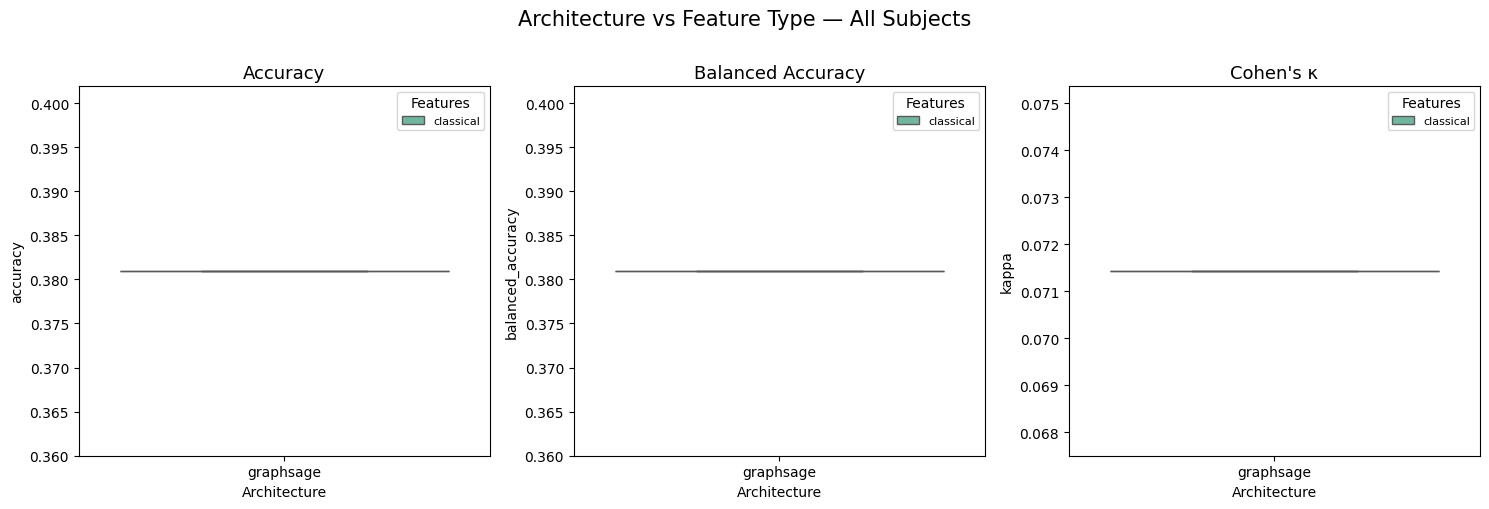

In [29]:
# Reload from CSV if needed: df = pd.read_csv('sweep_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, title) in zip(axes, [
    ('accuracy',          'Accuracy'),
    ('balanced_accuracy', 'Balanced Accuracy'),
    ('kappa',             "Cohen's κ"),
]):
    sns.boxplot(data=df, x='arch', y=metric, hue='feature_type', palette='Set2', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Architecture')
    ax.legend(title='Features', fontsize=8)
plt.suptitle('Architecture vs Feature Type — All Subjects', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('arch_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

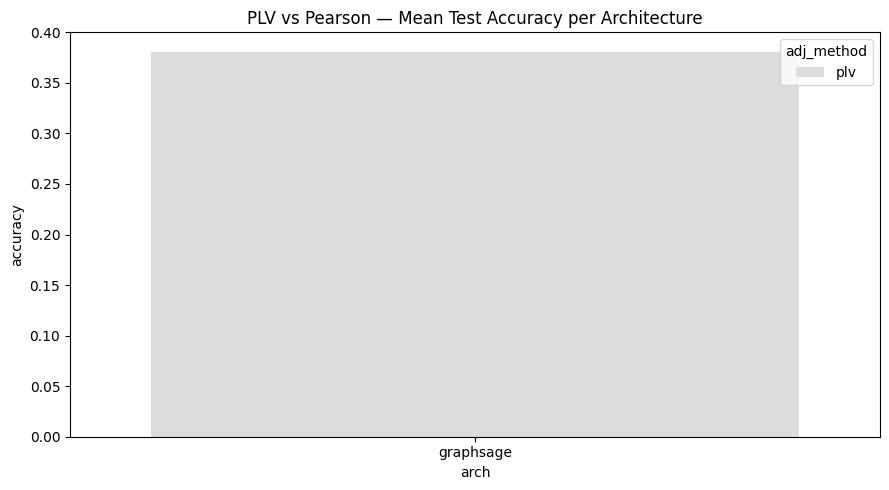

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='arch', y='accuracy', hue='adj_method',
            palette='coolwarm', capsize=0.1, ax=ax)
ax.set_title('PLV vs Pearson — Mean Test Accuracy per Architecture')
plt.tight_layout()
plt.savefig('plv_vs_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

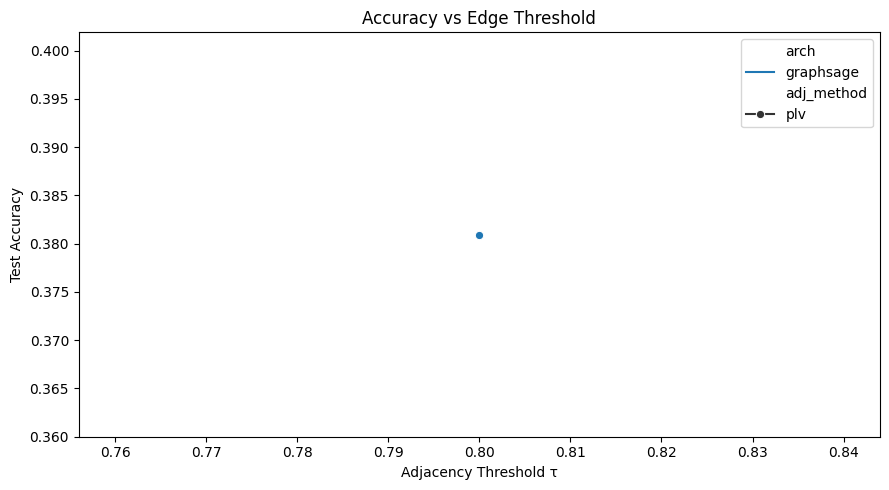

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=df, x='adj_threshold', y='accuracy', hue='arch',
             style='adj_method', markers=True, dashes=True, ax=ax)
ax.set_title('Accuracy vs Edge Threshold')
ax.set_xlabel('Adjacency Threshold τ')
ax.set_ylabel('Test Accuracy')
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

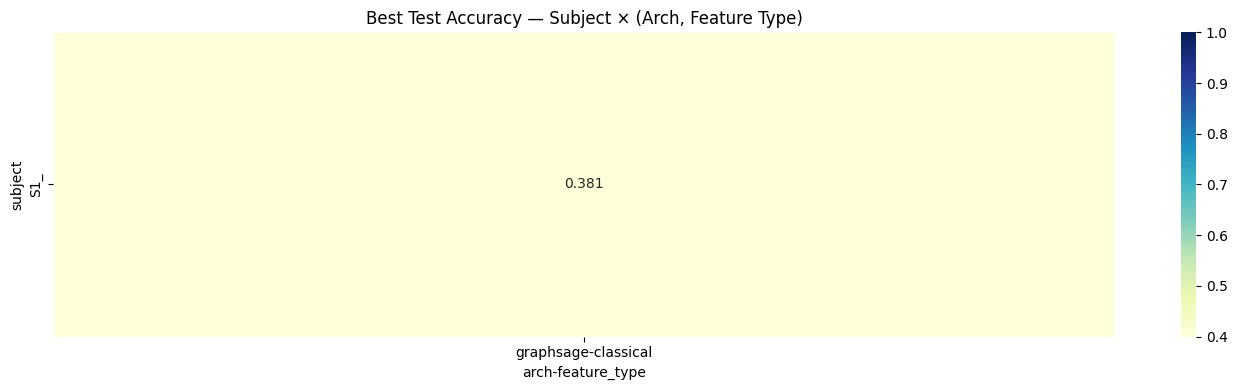

In [32]:
pivot = (
    df.groupby(['subject','arch','feature_type','adj_method'])['accuracy']
      .mean().reset_index()
      .pivot_table(index='subject', columns=['arch','feature_type'],
                   values='accuracy', aggfunc='max')
)
fig, ax = plt.subplots(figsize=(14, max(4, len(total_data))))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0)
ax.set_title('Best Test Accuracy — Subject × (Arch, Feature Type)')
plt.tight_layout()
plt.savefig('subject_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
summary = (
    df.groupby(['feature_type','adj_method','arch','adj_threshold','hidden_dim'])
      [['accuracy','balanced_accuracy','kappa','f1_macro']]
      .agg(['mean','std']).reset_index()
)
summary.columns = [' '.join(c).strip() for c in summary.columns]
summary = summary.sort_values('accuracy mean', ascending=False)
print("Top 10 configurations (averaged across subjects):")
display(summary.head(10))

Top 10 configurations (averaged across subjects):


,feature_type,adj_method,arch,adj_threshold,hidden_dim,accuracy mean,accuracy std,balanced_accuracy mean,balanced_accuracy std,kappa mean,kappa std,f1_macro mean,f1_macro std
0,classical,plv,graphsage,0.8,32,0.380952,NaN,0.380952,NaN,0.071429,NaN,0.256173,NaN


## 5. Best config — confusion matrices

In [ ]:
best_row = summary.iloc[0]
best_cfg = GNNConfig(
    feature_type  = best_row['feature_type'],
    adj_method    = best_row['adj_method'],
    arch          = best_row['arch'],
    adj_threshold = float(best_row['adj_threshold']),
    hidden_dim    = int(best_row['hidden_dim']),
    **SWEEP_FIXED,
    verbose       = True,
)
print(f"Best: feature={best_cfg.feature_type} | adj={best_cfg.adj_method} (τ={best_cfg.adj_threshold}) | arch={best_cfg.arch} | hidden={best_cfg.hidden_dim}")

In [ ]:
n_subj = len(total_data)
fig, axes = plt.subplots(1, n_subj, figsize=(5*n_subj, 4))
if n_subj == 1:
    axes = [axes]

for ax, (sid, subj_data) in zip(axes, total_data.items()):
    if sid not in test_data:
        ax.set_visible(False); continue
    m, _ = run_subject_train_test(
        subject_id=sid,
        train_windows=subj_data['data'], train_labels=subj_data['labels'],
        test_windows=test_data[sid]['data'], test_labels=test_data[sid]['labels'],
        cfg=best_cfg, n_classes=N_CLASSES,
    )
    cm = np.array(m['confusion_matrix'])
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
    cls_labels = [f'C{i}' for i in range(N_CLASSES)]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                vmin=0, vmax=1, xticklabels=cls_labels, yticklabels=cls_labels)
    ax.set_title(f"{sid}\nacc={m['accuracy']:.3f} | κ={m['kappa']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Best Config', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 5-Fold CV on best config

In [ ]:
cv_cfg = GNNConfig(
    feature_type  = best_cfg.feature_type,
    adj_method    = best_cfg.adj_method,
    arch          = best_cfg.arch,
    adj_threshold = best_cfg.adj_threshold,
    hidden_dim    = best_cfg.hidden_dim,
    n_cv_folds    = 5,
    **SWEEP_FIXED,
    verbose       = True,
)

cv_rows = []
for sid, subj_data in total_data.items():
    m, _ = run_subject_cv(
        subject_id=sid, windows=subj_data['data'],
        labels=subj_data['labels'], cfg=cv_cfg, n_classes=N_CLASSES,
    )
    cv_rows.append(dict(
        subject     = sid,
        acc_mean    = m['accuracy_mean'],
        acc_std     = m['accuracy_std'],
        kappa_mean  = m['kappa_mean'],
        kappa_std   = m['kappa_std'],
        bal_acc     = m['balanced_accuracy_mean'],
        f1_mean     = m['f1_macro_mean'],
    ))

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('cv_results.csv', index=False)
display(cv_df)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(max(10, len(cv_df)*2), 5))
for ax, (col_m, col_s, ylabel, title) in zip(axes, [
    ('acc_mean',   'acc_std',   'Accuracy',  '5-Fold CV Accuracy'),
    ('kappa_mean', 'kappa_std', "Cohen's κ", '5-Fold CV Kappa'),
]):
    ax.bar(cv_df['subject'], cv_df[col_m], yerr=cv_df[col_s],
           capsize=5, color='steelblue', alpha=0.8,
           error_kw={'elinewidth':2,'capthick':2})
    grand = cv_df[col_m].mean()
    ax.axhline(grand, color='firebrick', linestyle='--', linewidth=1.5,
               label=f'Mean={grand:.3f}')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cv_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()